In [1]:
import os
os.environ['KAGGLE_USERNAME'] = "Mitesh Reddy"
os.environ['KAGGLE_KEY'] = "KGAT_e087c0a11a31e7f33ca6d42687981bca"

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d chest_xray

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:26<00:00, 16.8MB/s]



In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder("chest_xray/chest_xray/train", transform=train_transform)
test_data = datasets.ImageFolder("chest_xray/chest_xray/test", transform=test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

print(f"Classes: {train_data.classes}")
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

Classes: ['NORMAL', 'PNEUMONIA']
Train batches: 163 | Test batches: 20


In [4]:
class ChestCNN(nn.Module):
    def __init__(self):
        super(ChestCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 2)
        )
    def forward(self, x):
        return self.fc_layers(self.conv_layers(x))

In [5]:
def train_model(model, train_loader, criterion, optimizer, epochs):
    model.train()
    history = []
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        acc = 100 * correct / total
        avg_loss = running_loss / len(train_loader)
        history.append((avg_loss, acc))
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - Accuracy: {acc:.2f}%")
    return history

In [6]:
def evaluate_model(model, test_loader, model_name):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"\n=== {model_name} Results ===")
    print(classification_report(all_labels, all_preds, target_names=['NORMAL', 'PNEUMONIA']))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()
    return all_preds, all_labels

Training Custom CNN...
Epoch 1/10 - Loss: 0.9213 - Accuracy: 85.22%
Epoch 2/10 - Loss: 0.2077 - Accuracy: 91.95%
Epoch 3/10 - Loss: 0.1717 - Accuracy: 93.63%
Epoch 4/10 - Loss: 0.1602 - Accuracy: 94.06%
Epoch 5/10 - Loss: 0.1556 - Accuracy: 94.80%
Epoch 6/10 - Loss: 0.1310 - Accuracy: 95.09%
Epoch 7/10 - Loss: 0.1523 - Accuracy: 94.44%
Epoch 8/10 - Loss: 0.1410 - Accuracy: 94.96%
Epoch 9/10 - Loss: 0.1125 - Accuracy: 96.17%
Epoch 10/10 - Loss: 0.1278 - Accuracy: 95.19%

=== Custom CNN Results ===
              precision    recall  f1-score   support

      NORMAL       0.98      0.46      0.63       234
   PNEUMONIA       0.75      0.99      0.86       390

    accuracy                           0.79       624
   macro avg       0.87      0.73      0.74       624
weighted avg       0.84      0.79      0.77       624



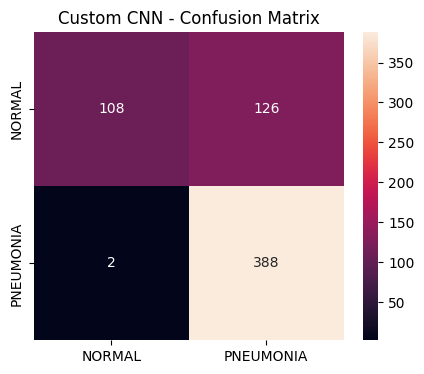

In [7]:
cnn_model = ChestCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

print("Training Custom CNN...")
cnn_history = train_model(cnn_model, train_loader, criterion, optimizer, epochs=10)
torch.save(cnn_model.state_dict(), "custom_cnn.pth")
cnn_preds, cnn_labels = evaluate_model(cnn_model, test_loader, "Custom CNN")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]


Training ResNet18...
Epoch 1/10 - Loss: 0.1381 - Accuracy: 94.54%
Epoch 2/10 - Loss: 0.0652 - Accuracy: 97.62%
Epoch 3/10 - Loss: 0.0601 - Accuracy: 97.81%
Epoch 4/10 - Loss: 0.0458 - Accuracy: 98.35%
Epoch 5/10 - Loss: 0.0424 - Accuracy: 98.27%
Epoch 6/10 - Loss: 0.0296 - Accuracy: 98.96%
Epoch 7/10 - Loss: 0.0312 - Accuracy: 98.85%
Epoch 8/10 - Loss: 0.0240 - Accuracy: 99.23%
Epoch 9/10 - Loss: 0.0218 - Accuracy: 99.18%
Epoch 10/10 - Loss: 0.0245 - Accuracy: 99.14%

=== ResNet18 Results ===
              precision    recall  f1-score   support

      NORMAL       0.97      0.75      0.85       234
   PNEUMONIA       0.87      0.99      0.92       390

    accuracy                           0.90       624
   macro avg       0.92      0.87      0.88       624
weighted avg       0.91      0.90      0.89       624



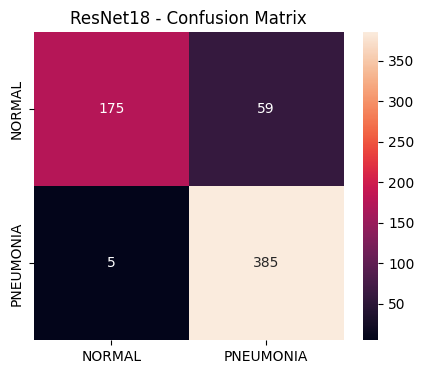

In [8]:
resnet_model = models.resnet18(pretrained=True)
resnet_model.fc = nn.Linear(512, 2)
resnet_model = resnet_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.parameters(), lr=0.0001)

print("Training ResNet18...")
resnet_history = train_model(resnet_model, train_loader, criterion, optimizer, epochs=10)
torch.save(resnet_model.state_dict(), "resnet18.pth")
resnet_preds, resnet_labels = evaluate_model(resnet_model, test_loader, "ResNet18")

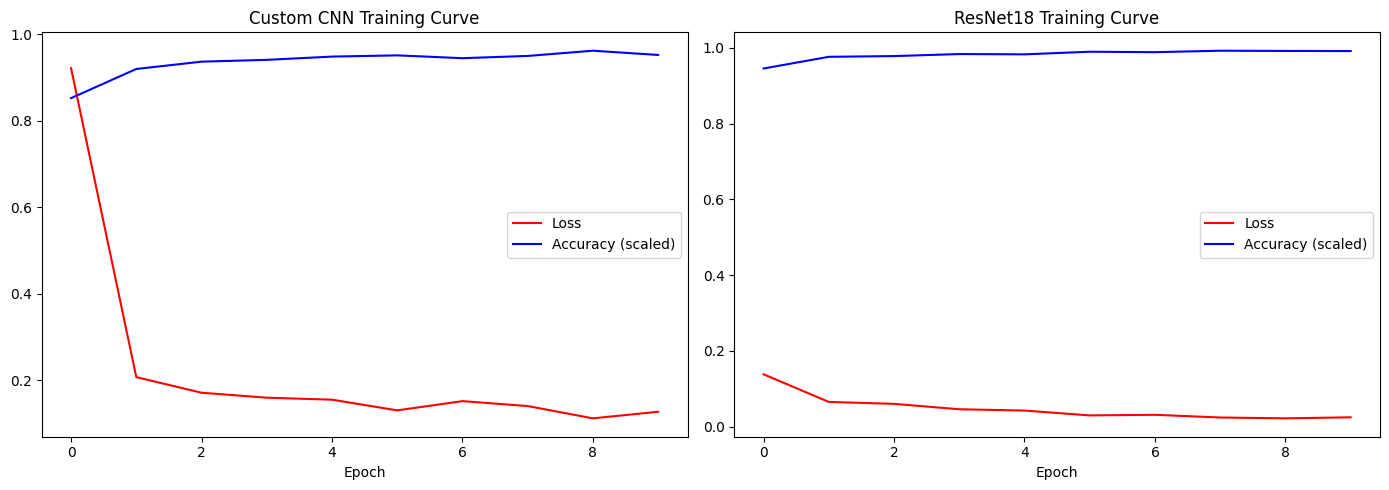

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, name in zip(axes, [cnn_history, resnet_history], ["Custom CNN", "ResNet18"]):
    losses = [h[0] for h in history]
    accs = [h[1] for h in history]
    ax.plot(losses, label="Loss", color="red")
    ax.plot([a/100 for a in accs], label="Accuracy (scaled)", color="blue")
    ax.set_title(f"{name} Training Curve")
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

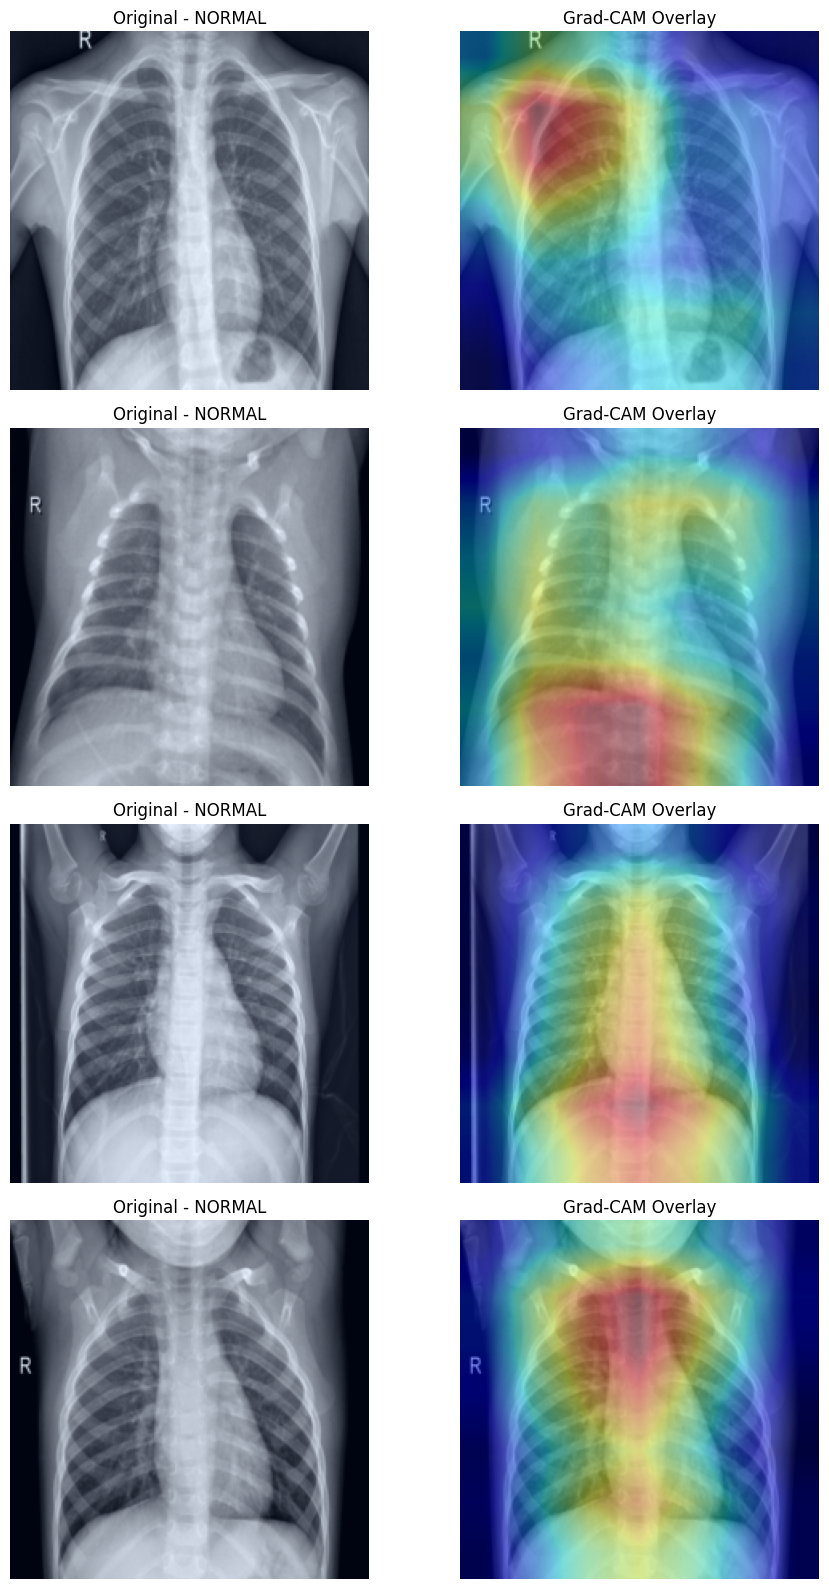

In [12]:
from PIL import Image as PILImage
import cv2

def grad_cam_overlay(model, image_tensor, target_class):
    model.eval()
    features, grads = [], []

    def fhook(m, i, o): features.append(o)
    def bhook(m, i, o): grads.append(o[0])

    h1 = model.layer4[1].conv2.register_forward_hook(fhook)
    h2 = model.layer4[1].conv2.register_backward_hook(bhook)
    out = model(image_tensor.unsqueeze(0).to(device))
    model.zero_grad()
    out[0][target_class].backward()

    pooled = grads[0].mean(dim=[0, 2, 3])
    act = features[0].squeeze(0).cpu().detach()
    for i in range(act.shape[0]):
        act[i] *= pooled[i].cpu()

    heatmap = act.mean(0).numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap /= heatmap.max() + 1e-8
    heatmap = cv2.resize(heatmap, (224, 224))

    h1.remove()
    h2.remove()
    return heatmap

fig, axes = plt.subplots(4, 2, figsize=(10, 16))
for i in range(4):
    image, label = test_data[i * 50]
    heatmap = grad_cam_overlay(resnet_model, image, label)

    img_np = image.permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    axes[i][0].imshow(img_np, cmap='gray')
    axes[i][0].set_title(f"Original - {'NORMAL' if label==0 else 'PNEUMONIA'}")
    axes[i][0].axis('off')

    axes[i][1].imshow(img_np, cmap='gray')
    axes[i][1].imshow(heatmap, cmap='jet', alpha=0.4)
    axes[i][1].set_title(f"Grad-CAM Overlay")
    axes[i][1].axis('off')

plt.tight_layout()
plt.savefig("gradcam.png", dpi=150)
plt.show()